# 06 — Train a complete MLP from scratch on real digits 0 vs 1

Now we scale the same mechanics to all 64 pixels and hundreds of real samples. There is still no autograd framework.

Architecture: **64 → 8 tanh units → 1 sigmoid output**.

## What you should learn
- batch forward propagation;
- batch BCE loss;
- matrix-form backpropagation;
- train/test separation;
- learning curves, confusion matrix, hard examples;
- what hidden-unit weight images look like after learning.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.set_printoptions(precision=5, suppress=True)
RNG = np.random.default_rng(42)

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
d=load_digits();mask=np.isin(d.target,[0,1]);X=d.data[mask]/16.0;y=(d.target[mask]==1).astype(float).reshape(-1,1)
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=.25,random_state=42,stratify=y)
print('train',Xtr.shape,'test',Xte.shape)


train (270, 64) test (90, 64)


In [2]:
rng=np.random.default_rng(7)
W1=rng.normal(0,.15,(64,8));b1=np.zeros((1,8));W2=rng.normal(0,.15,(8,1));b2=np.zeros((1,1))
def sigmoid(z):return 1/(1+np.exp(-z))
def forward(X_):
    z1=X_@W1+b1;a1=np.tanh(z1);z2=a1@W2+b2;p=sigmoid(z2);return z1,a1,z2,p
def bce(y_,p):
    e=1e-9;return -np.mean(y_*np.log(p+e)+(1-y_)*np.log(1-p+e))
history=[];snapshots={};lr=.6
for epoch in range(401):
    z1,a1,z2,p=forward(Xtr);loss=bce(ytr,p)
    if epoch in [0,1,5,20,100,400]: snapshots[epoch]=(loss,W1.copy(),W2.copy())
    dz2=(p-ytr)/len(Xtr);dW2=a1.T@dz2;db2=dz2.sum(0,keepdims=True)
    da1=dz2@W2.T;dz1=da1*(1-a1**2);dW1=Xtr.T@dz1;db1=dz1.sum(0,keepdims=True)
    W2-=lr*dW2;b2-=lr*db2;W1-=lr*dW1;b1-=lr*db1
    if epoch%5==0: history.append((epoch,loss,np.linalg.norm(dW1),np.linalg.norm(dW2)))
hist=pd.DataFrame(history,columns=['epoch','loss','||dW1||','||dW2||']);hist.tail()


,epoch,loss,||dW1||,||dW2||
76,380,0.000986,0.001197,0.001825
77,385,0.000971,0.001179,0.001800
78,390,0.000958,0.001163,0.001776
79,395,0.000944,0.001146,0.001752
80,400,0.000931,0.001131,0.001729


test accuracy: 1.0


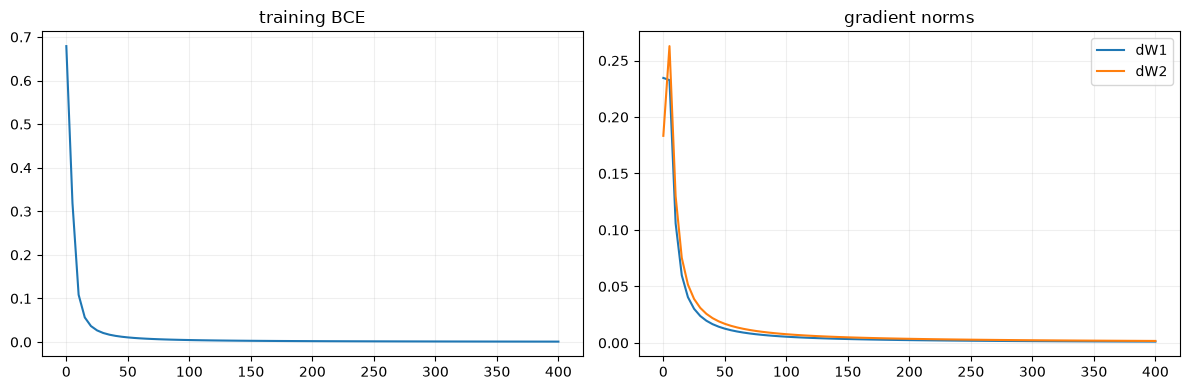

In [3]:
_,_,_,pte=forward(Xte);pred=(pte>=.5).astype(int);acc=accuracy_score(yte,pred)
print('test accuracy:',acc)
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].plot(hist.epoch,hist.loss);axes[0].set_title('training BCE');axes[0].grid(alpha=.2)
axes[1].plot(hist.epoch,hist['||dW1||'],label='dW1');axes[1].plot(hist.epoch,hist['||dW2||'],label='dW2');axes[1].set_title('gradient norms');axes[1].legend();axes[1].grid(alpha=.2)
plt.tight_layout();plt.show()


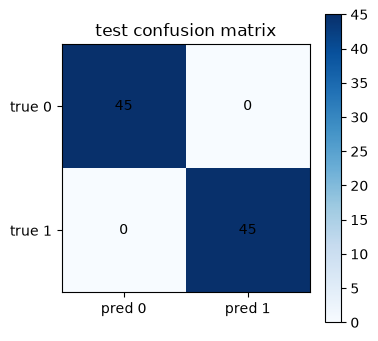

In [4]:
cm=confusion_matrix(yte.astype(int).ravel(),pred.ravel())
fig,ax=plt.subplots(figsize=(4,4));im=ax.imshow(cm,cmap='Blues');
for i in range(2):
    for j in range(2):ax.text(j,i,str(cm[i,j]),ha='center',va='center')
ax.set_xticks([0,1],['pred 0','pred 1']);ax.set_yticks([0,1],['true 0','true 1']);ax.set_title('test confusion matrix');plt.colorbar(im,ax=ax);plt.show()


## Hidden units as learned pixel templates
Each hidden neuron has 64 incoming weights. Reshape them to 8×8 to see what pixel patterns it responds positively/negatively to.


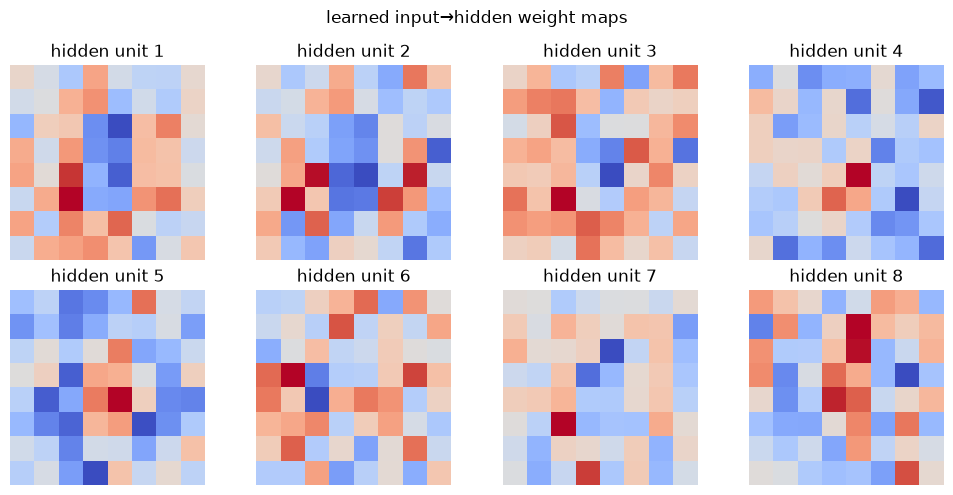

In [5]:
fig,axes=plt.subplots(2,4,figsize=(10,5))
for j,ax in enumerate(axes.ravel()):
    im=ax.imshow(W1[:,j].reshape(8,8),cmap='coolwarm');ax.set_title(f'hidden unit {j+1}');ax.axis('off')
plt.suptitle('learned input→hidden weight maps');plt.tight_layout();plt.show()


## Hard examples: inspect uncertainty instead of only accuracy


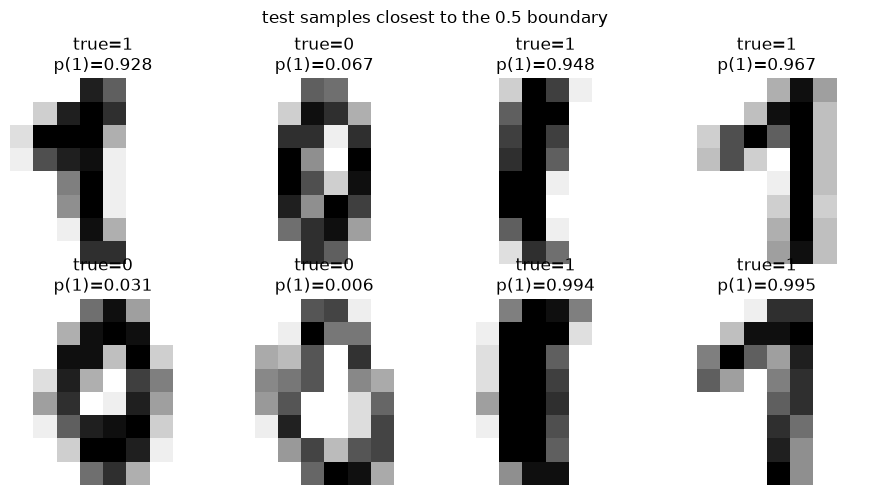

In [6]:
order=np.argsort(np.abs(pte.ravel()-.5))[:8]
fig,axes=plt.subplots(2,4,figsize=(9,5))
for ax,i in zip(axes.ravel(),order):
    ax.imshow(Xte[i].reshape(8,8),cmap='gray_r');ax.set_title(f'true={int(yte[i,0])}\np(1)={pte[i,0]:.3f}');ax.axis('off')
plt.suptitle('test samples closest to the 0.5 boundary');plt.tight_layout();plt.show()


## Inference / insight
The training curve tells us whether optimization progressed; the confusion matrix tells us which decision errors remain; the hidden weight maps tell us what internal detectors were formed; the hard-example panel tells us where the model is uncertain. A gold-standard evaluation uses all of these views together.
